In [1]:
import numpy as np

x = np.array([4,-3,7,1])

l1 = np.linalg.norm(x,1)
l2 = np.linalg.norm(x,2)
linf = np.linalg.norm(x,np.inf)

print("L1:",l1)
print("L2:",l2)
print("L~:",linf)


L1: 15.0
L2: 8.660254037844387
L~: 7.0


In [5]:
import numpy as np
import pandas as pd
from sklearn.linear_model import Lasso
from sklearn.metrics.pairwise import euclidean_distances

#Create dataset
data ={
    "Hours_Studied": [2,4,6,8,10],
    "Attendance": [50,60,70,80,90],
    "Sleep Hours": [6,7,5,6,7],
    "Shoe_Size": [6,7,8,9,10],  #irrelevant feature
    "Score": [40,50,65,80,90]
}

df = pd.DataFrame(data)

X = df.drop("Score",axis=1) #Seperate features and Target...all columns except score is considered
y = df["Score"]

print("Dataset:\n",df)

#Step 2: L1 Norm: Feature selection

lasso = Lasso(alpha=0.1)
lasso.fit(X,y)

print("\nL1 (Lasso) Coeffiecients:")
for feature,coef in zip(X.columns, lasso.coef_):
    print(f"{feature}:{coef: .4f}")

#Step 3: L2 Norm -- student similarity

student1 = X.iloc[0].values.reshape(1,-1)
student2 = X.iloc[4].values.reshape(1,-1)

distance = euclidean_distances(student1, student2)

print("\nL2 Distance between Student 1 and Student 5:",distance[0][0])

#Step 4: L~ Norm >> Max error check

predictions = lasso.predict(X)

errors = np.abs(predictions-y)
linf_error = np.max(errors)

print("\nPredictions:",predictions)
print("Actual:",list(y))
print("Errors:",errors)
print("L~ Norm (Max error):",linf_error)




Dataset:
    Hours_Studied  Attendance  Sleep Hours  Shoe_Size  Score
0              2          50            6          6     40
1              4          60            7          7     50
2              6          70            5          8     65
3              8          80            6          9     80
4             10          90            7         10     90

L1 (Lasso) Coeffiecients:
Hours_Studied: 0.0000
Attendance: 1.3087
Sleep Hours:-0.9241
Shoe_Size: 0.0000

L2 Distance between Student 1 and Student 5: 41.0

Predictions: [39.01       51.17333333 66.10888889 78.27222222 90.43555556]
Actual: [40, 50, 65, 80, 90]
Errors: 0    0.990000
1    1.173333
2    1.108889
3    1.727778
4    0.435556
Name: Score, dtype: float64
L~ Norm (Max error): 1.7277777777777459


Dot Product: -8
Vectors are NOT Orthogonal


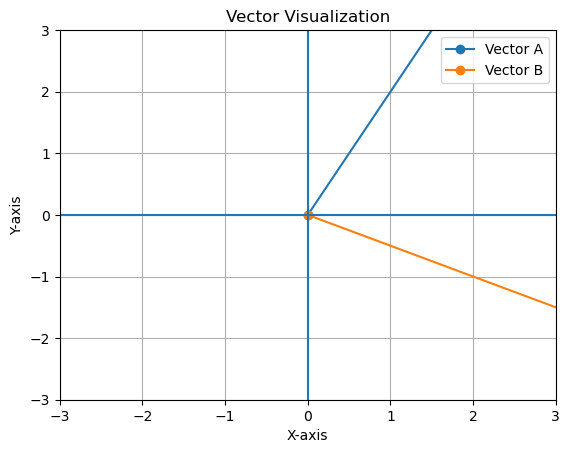

In [13]:
import numpy as np
import matplotlib.pyplot as plt

A = np.array([2,4,6,8])
B =np.array([4,-2,-4,2])

dot_product = np.dot(A,B)

print("Dot Product:", dot_product)

if dot_product == 0:
    print("Vectors are Orthogonal (Perpendicular)")
else:
    print("Vectors are NOT Orthogonal")


origin = [0, 0]

plt.plot([0, A[0]], [0, A[1]], marker='o', label='Vector A')
plt.plot([0, B[0]], [0, B[1]], marker='o', label='Vector B')

# Axes
plt.xlim(-3, 3)
plt.ylim(-3, 3)

plt.axhline(0)  # X-axis
plt.axvline(0)  # Y-axis

plt.grid()
plt.legend()

plt.title("Vector Visualization")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")

plt.show()

Original dataset:
    income  color
0   25000    Red
1   50000   Blue
2   75000  Green
3   30000   Blue
4   90000    Red

Encoded Dataset:
    income  color_Blue  color_Green  color_Red
0   25000         0.0          0.0        1.0
1   50000         1.0          0.0        0.0
2   75000         0.0          1.0        0.0
3   30000         1.0          0.0        0.0
4   90000         0.0          0.0        1.0

Dot Product (Income vs Red): 115000.0
Correlation between Income and Red: 0.11349527614696626


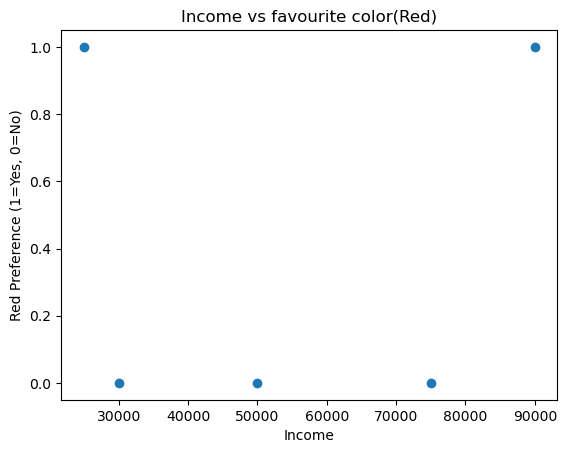

In [18]:
import numpy as np
import pandas  as pd
import matplotlib.pyplot as plt
from  sklearn.preprocessing import OneHotEncoder  #converts categorical data(color) into numeric form

#Create dataset
data = {
    "income": [25000,50000,75000, 30000, 90000],
    "color": ["Red", "Blue", "Green","Blue","Red"]
}

df= pd.DataFrame(data)
print("Original dataset:\n",df)   #converts table


#One-Hot Encoding
encoder = OneHotEncoder(sparse_output = False)
color_encoded = encoder.fit_transform(df[["color"]])   #Creates encoder.... sparse=False-> output as normal array(not space matrix)

color_df = pd.DataFrame(color_encoded, columns = encoder.get_feature_names_out()) # converts encoded values into a labeled table

#Combine income with encoded colors
X = pd.concat([df["income"],color_df],axis =1) #combine income columnm, 

print("\nEncoded Dataset:\n",X)


#Step 3: Dot product

income_vector = X["income"].values
red_vector = X["color_Red"].values   #Extract two vectors ...income values, red preference

dot_product = np.dot(income_vector, red_vector)
print("\nDot Product (Income vs Red):",dot_product)


#Step 4: Correlation

correlation = np.corrcoef(income_vector, red_vector)[0,1]
print("Correlation between Income and Red:", correlation)

#Step 5: Visualization

plt.figure()
plt.scatter(income_vector, red_vector)

plt.xlabel("Income")
plt.ylabel("Red Preference (1=Yes, 0=No)")
plt.title("Income vs favourite color(Red)")


plt.show()


Query Digit: 0

 Top similar image indices: [ 10 334 812 256 160 848]
Similarity Scores: [1.         0.96493807 0.95939227 0.95478125 0.95323395 0.95290124]


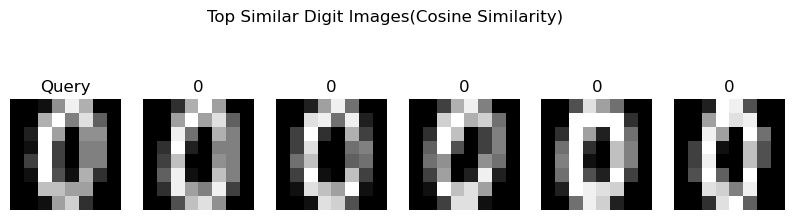

In [21]:
#digit image similarity search

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.metrics.pairwise import cosine_similarity

#Load dataset

digits = load_digits()
X = digits.data  #shape(1797, 64)
y= digits.target

#Select Query Image

query_index= 10
query_image = X[query_index]

print("Query Digit:", y[query_index])

#Compute Cosine similarity

similarities = cosine_similarity([query_image],X)[0]

#get top 5 similar images 

top_indices = np.argsort(similarities)[-6:][::-1] #top 6(including itself)

print("\n Top similar image indices:", top_indices)
print("Similarity Scores:", similarities[top_indices])

#visualization

plt.figure(figsize=(10,3))

#Show Query Image
plt.subplot(1,6,1)
plt.imshow(query_image.reshape(8,8), cmap='gray')
plt.title("Query")
plt.axis('off')

#Show Top Matches
for i, idx in enumerate(top_indices[1:]):   #skip itself
    plt.subplot(1,6,i+2)
    plt.imshow(X[idx].reshape(8,8), cmap='gray')
    plt.title(f"{y[idx]}")
    plt.axis('off')

plt.suptitle("Top Similar Digit Images(Cosine Similarity)")
plt.show()

In [ ]:
#Movie Recommondation System




In [ ]:
#Resume Matching